# Обучение моделей: цена в объявлении

Задача - предсказать, какую цену следует поставить, чтобы продать квартиру за желаемый срок. Целевой признак - price_per_m2. Считаем по тем же закрытым объявлениям, что и в модели ликвидности

# Импортируем библиотеки

In [ ]:
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold

from sklearn.preprocessing import StandardScaler, OneHotEncoder

# простые модели
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
# Ансамбли
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error, make_scorer


# Строим функции и фиксируем константы

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

In [ ]:
def preprocessor_creator(ohe_cols,
                         num_cols):
    '''
    Функция для построения пайплайна кодирования данных
    Категориальные признаки кодируем ohe, числовые шкалером
    '''

    # кодировщик категориальных признаков
    ohe_pipe = Pipeline(
        [
            ('simpleImputer_ohe', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(drop='first',
                                  handle_unknown='ignore',
                                  sparse_output=True))
        ]
    )

    # кодировщик числовых признаков
    scaler_pipe = Pipeline(
        [
            ('simpleImputer_num', SimpleImputer(strategy='median')),
            ('standard', StandardScaler(with_mean=False))
        ]
    )

    data_preprocessor = ColumnTransformer([
        ('ohe', ohe_pipe, ohe_cols),
        ('num', scaler_pipe, num_cols)])

    return data_preprocessor

In [4]:
def col_names_func(df):
    '''
    функция для разделения столбцов по типам
    '''
    num_col_names = df.select_dtypes(include='number').columns.tolist()
    cat_col_names = df.select_dtypes(exclude='number').columns.tolist()
    return num_col_names, cat_col_names

In [5]:
def evaluate_model(y_true, y_pred):
    '''
    Принимает фактические значения и предсказания
    Выводит на экран основные метрики регрессии и возвращает их значения
    '''
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R2: {r2:.3f}')

    return mae, rmse, r2

# Загрузка данных

In [6]:
df = pd.read_csv('./data/data_final.csv')
df.shape

(140778, 58)

## Отбор модельных признаков

In [ ]:
# убираем производные от цены типа ppm_to_district и last_price
num_cols = [
    'mortgage_allowed', 'n_metro', 'nearest_metro_time', 'nearest_metro_walk', 'rooms', 'is_studio',
    'total_area', 'living_area', 'kitchen_area', 'floor', 'total_floors', 'ceiling_height',
    'is_apartments', 'is_new_building', 'phone_protected', 'lat', 'lon', 'dist_to_center',
    'building_age', 'is_ready', 'is_first_floor', 'is_last_floor', 'floor_ratio',
    'living_to_total', 'kitchen_to_total', 'area_per_room',
    'total_lifts', 'has_lift', 'bath_separate', 'bath_combined', 'balcony_count', 'loggia_count',
    'completion_year', 'years_to_completion', 'is_presale', 'has_completion',
    'days_on_market'
]
cat_cols = ['region', 'flat_type', 'renovation', 'window_view', 'building_type', 'parking',
            'seller_type', 'deal_conditions', 'municipality', 'district']

df = df[num_cols + cat_cols + ['price_per_m2']].copy()
display(df.shape)
display(df.head())

# Модель

In [8]:
# Целевой признак регрессии - цена за м2
y_reg = df['price_per_m2'].astype(float)
X_reg = df.drop(columns='price_per_m2')

X_train, X_test, y_train, y_test = train_test_split(X_reg,
                                                    y_reg,
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE)

num_cols, cat_cols = col_names_func(X_train)
preprocessor = preprocessor_creator(cat_cols, num_cols)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

display(X_train_encoded.shape)
display(X_test_encoded.shape)

c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


(112622, 413)

(28156, 413)

Прогоняем кросс-валидацию с поиском по сетке. Сначала простые модели (линейная регрессия и дерево) как бейзлайн, потом бустинг. Данных много (140к строк), поэтому из бустингов взял только LGBM. Метрика - RMSE.

In [10]:
pipe_reg = Pipeline([('models', LGBMRegressor(random_state=RANDOM_STATE, verbose=-1))])
kf = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scorer = make_scorer(root_mean_squared_error, greater_is_better=False)

simple_reg_params = [
        # Линейная регрессия
        {
            'models': [LinearRegression()]
        },

        # Дерево решений
        {
            'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
            'models__max_depth': [6, 9, 12],
            'models__min_samples_leaf': [30, 60]
        }
]

rscv = RandomizedSearchCV(
    pipe_reg,
    simple_reg_params,
    n_iter=6,
    cv=kf,
    scoring=scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rscv_simple_reg = rscv.fit(X_train_encoded, y_train)
simple_reg = rscv_simple_reg.best_estimator_

print('Лучшая простая модель:', simple_reg['models'])
print('Метрики на тесте')
evaluate_model(y_test, simple_reg.predict(X_test_encoded))

Лучшая простая модель: DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=42)
Метрики на тесте
MAE: 37431.03
RMSE: 58434.94
R2: 0.879


(37431.02587136524, np.float64(58434.93987394104), 0.8790989163268202)

In [11]:
boosters_reg_params = [
        # LGBM
        {
            'models': [LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)],
            'models__n_estimators': [500, 1000, 1500],
            'models__learning_rate': [0.03, 0.05],
            'models__num_leaves': [60, 120],
            'models__subsample': [0.8, 1.0],
            'models__colsample_bytree': [0.8, 1.0],
            'models__reg_lambda': [0.0, 1.0]
        }
]

rscv = RandomizedSearchCV(
    pipe_reg,
    boosters_reg_params,
    n_iter=10,
    cv=kf,
    scoring=scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rscv_boost_reg = rscv.fit(X_train_encoded, y_train)
model_reg = rscv_boost_reg.best_estimator_

print('Лучший бустинг:', model_reg['models'])
print('Метрики лучшей модели на трейне')
evaluate_model(y_train, model_reg.predict(X_train_encoded))
print()
print('Метрики лучшей модели на тесте')
evaluate_model(y_test, model_reg.predict(X_test_encoded))

Лучший бустинг: LGBMRegressor(learning_rate=0.05, n_estimators=1500, num_leaves=127,
              random_state=42, reg_lambda=1.0, subsample=0.8, verbose=-1)
Метрики лучшей модели на трейне


c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 12790.44
RMSE: 18755.42
R2: 0.987

Метрики лучшей модели на тесте


c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MAE: 22836.17
RMSE: 38624.13
R2: 0.947


(22836.174179617836, np.float64(38624.13000849059), 0.9471795117809214)

Важность признаков регрессора.

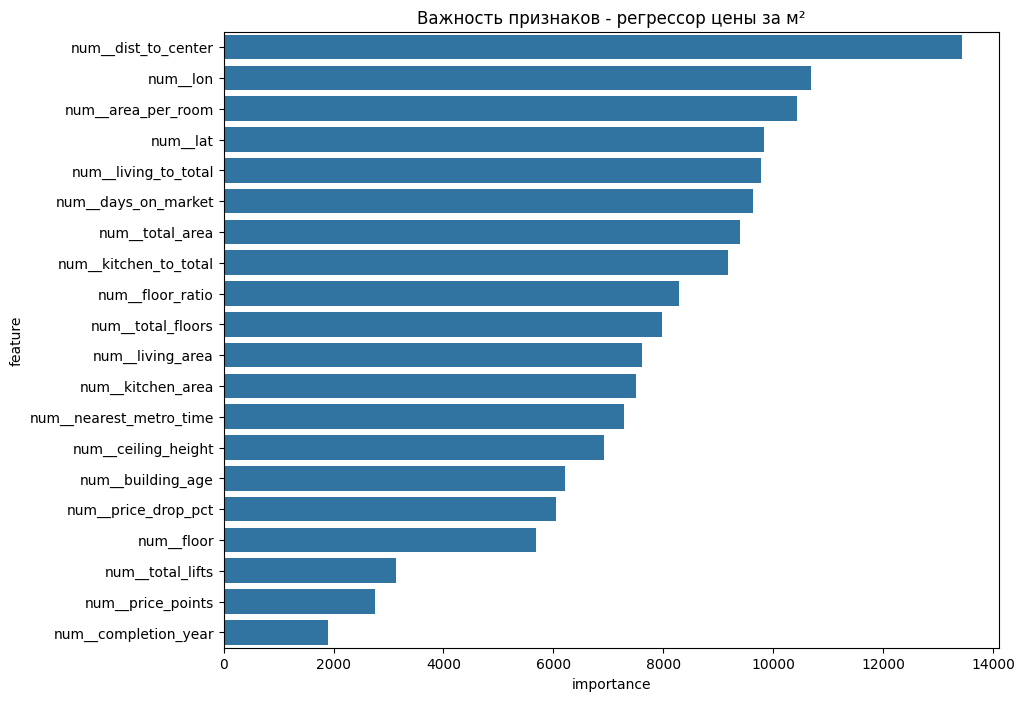

In [12]:
imp_reg = pd.DataFrame({
    'feature': feature_names,
    'importance': model_reg['models'].feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=imp_reg)
plt.title('Важность признаков - регрессор цены за м2')
plt.show()

### Восстановление полной цены

In [13]:
# Восстановление полной цены объявления для валидации
pred_ppm2 = model_reg.predict(X_test_encoded)
pred_price = pred_ppm2 * X_test['total_area'].values
true_price = y_test.values * X_test['total_area'].values

print('Метрики по полной цене объявления (руб)')
evaluate_model(true_price, pred_price)

c:\Users\Никита\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Метрики по полной цене объявления (руб)
MAE: 1340432.56
RMSE: 2634817.77
R2: 0.961


(1340432.555795651, np.float64(2634817.7723114574), 0.9614134805554828)

### Нейросеть для регрессии

In [14]:
# импорт нейронки
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# если в системе есть видеокарта - считаем на ней
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Устройство для обучения:', device)

# переводим данные в тензоры
X_train_dense = X_train_encoded.toarray().astype('float32')
X_test_dense = X_test_encoded.toarray().astype('float32')

X_train_t = torch.tensor(X_train_dense)
X_test_t = torch.tensor(X_test_dense)

# шкалируем цену
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).astype('float32')

y_train_t = torch.tensor(y_train_scaled)

# заворачиваем трейн в DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

print('Размер обучающей матрицы:', X_train_t.shape)

Устройство для обучения: cuda
Размер обучающей матрицы: torch.Size([112622, 413])


In [15]:
# Простая полносвязная нейросеть
class Net(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.fc1 = nn.Linear(n_features, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# отправляем нейронку на GPU
model = Net(X_train_t.shape[1]).to(device)
print(model)

Net(
  (fc1): Linear(in_features=413, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
)


In [ ]:
# берём mse как функцию потерь
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# задаём количество эпох
epochs = 100
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        # переносим батч на видеокарту
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # средняя ошибка за эпоху по всем батчам
    mean_loss = epoch_loss / len(train_loader)
    if (epoch + 1) % 10 == 0:
        print(f'Эпоха {epoch + 1}/{epochs}, ошибка (MSE): {mean_loss:.4f}')

Эпоха 10/1000, ошибка (MSE, станд. шкала): 0.163
Эпоха 20/1000, ошибка (MSE, станд. шкала): 0.127
Эпоха 30/1000, ошибка (MSE, станд. шкала): 0.111
Эпоха 40/1000, ошибка (MSE, станд. шкала): 0.102
Эпоха 50/1000, ошибка (MSE, станд. шкала): 0.095
Эпоха 60/1000, ошибка (MSE, станд. шкала): 0.091
Эпоха 70/1000, ошибка (MSE, станд. шкала): 0.085
Эпоха 80/1000, ошибка (MSE, станд. шкала): 0.085
Эпоха 90/1000, ошибка (MSE, станд. шкала): 0.082
Эпоха 100/1000, ошибка (MSE, станд. шкала): 0.080
Эпоха 110/1000, ошибка (MSE, станд. шкала): 0.077
Эпоха 120/1000, ошибка (MSE, станд. шкала): 0.075
Эпоха 130/1000, ошибка (MSE, станд. шкала): 0.074
Эпоха 140/1000, ошибка (MSE, станд. шкала): 0.071
Эпоха 150/1000, ошибка (MSE, станд. шкала): 0.070
Эпоха 160/1000, ошибка (MSE, станд. шкала): 0.067
Эпоха 170/1000, ошибка (MSE, станд. шкала): 0.068
Эпоха 180/1000, ошибка (MSE, станд. шкала): 0.066
Эпоха 190/1000, ошибка (MSE, станд. шкала): 0.065
Эпоха 200/1000, ошибка (MSE, станд. шкала): 0.062
Эпоха 210

In [ ]:
# смотрим качество на тесте
model.eval()
with torch.no_grad():
    y_pred_nn_scaled = model(X_test_t.to(device)).cpu().numpy().reshape(-1, 1)

# возвращаем предсказание из стандартизованной шкалы обратно в руб/м2
y_pred_nn = y_scaler.inverse_transform(y_pred_nn_scaled).reshape(-1)

print('Метрики нейросети на тесте')
evaluate_model(y_test, y_pred_nn)

Метрики нейросети на тесте
MAE: 30307.14
RMSE: 50105.02
R2: 0.911


(30307.140405923597, np.float64(50105.02378901808), 0.9111110991707176)

: 

# Выводы

лучшая модель - lgbm с метрикой mae=22000 рублей за квадратный метр. Нейронка отработала ещё хуже, чем в задаче прогнозирования квартир